In [ ]:
# =============================================================================
# 1 — Imports
# =============================================================================
# Core libraries for plotting, numerical operations and PyTorch.
# torchvision gives datasets, transforms and image utilities.

import matplotlib.pyplot as plt
import numpy as np

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [4]:
# =============================================================================
# 2 — Data preparation
# =============================================================================
# Compose a transform pipeline:
#   1. ToTensor()  — converts PIL images to tensors with values in [0, 1]
#   2. Normalize((0.5,), (0.5,)) — shifts range to [-1, 1]
#      Formula: (pixel - 0.5) / 0.5   →  0 becomes -1, 1 becomes +1
#      Single-element tuples because Fashion-MNIST is grayscale (1 channel).

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download Fashion-MNIST training and test splits into ./data
trainset = torchvision.datasets.FashionMNIST(
    './data', download=True, train=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(
    './data', download=True, train=False, transform=transform)

# DataLoaders handle batching and shuffling.
# batch_size=4 means each iteration yields 4 images + 4 labels.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False)

# Human-readable class names (indices 0–9 map to these strings)
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

100.0%
100.0%
100.0%
100.0%


In [5]:
# =============================================================================
# 3 — Helper: display an image with matplotlib
# =============================================================================
# Used later by plot_classes_preds to render predictions.
# The unnormalize step reverses the Normalize((0.5,),(0.5,)) transform:
#   original = (normalized * 0.5) + 0.5

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)          # average across channels → 2-D
    img = img / 2 + 0.5               # unnormalize back to [0, 1]
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))  # CHW → HWC for matplotlib


In [6]:
# =============================================================================
# 4 — Define the CNN
# =============================================================================
# A small LeNet-style network adapted for 28×28 grayscale images:
#
# Input: 1×28×28
#   → Conv2d(1→6, 5×5)  → 6×24×24   (no padding, so spatial dims shrink by 4)
#   → ReLU → MaxPool(2)  → 6×12×12
#   → Conv2d(6→16, 5×5) → 16×8×8
#   → ReLU → MaxPool(2)  → 16×4×4
#   → Flatten to 256
#   → FC(256→120) → ReLU
#   → FC(120→84)  → ReLU
#   → FC(84→10)           (raw logits for 10 classes)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)       # 1 input channel, 6 output filters, 5×5 kernel
        self.pool = nn.MaxPool2d(2, 2)         # 2×2 pooling with stride 2 (halves spatial dims)
        self.conv2 = nn.Conv2d(6, 16, 5)       # 6→16 filters
        self.fc1 = nn.Linear(16 * 4 * 4, 120)  # 16 filters × 4×4 spatial = 256 inputs
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)            # 10 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # conv → relu → pool
        x = self.pool(F.relu(self.conv2(x)))   # conv → relu → pool
        x = x.view(-1, 16 * 4 * 4)            # flatten for fully-connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                        # no softmax here — CrossEntropyLoss handles it
        return x

net = Net()

In [7]:
# =============================================================================
# 5 — Loss function and optimizer
# =============================================================================
# CrossEntropyLoss = LogSoftmax + NLLLoss combined.  Expects raw logits.
# SGD with momentum is a classic baseline optimizer.

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)


In [9]:
# =============================================================================
# 6 — Set up TensorBoard writer
# =============================================================================
# SummaryWriter creates a log directory on disk. All add_* calls below
# serialize data there; TensorBoard reads from it to render the UI.

from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter('runs/fashion_mnist_experiment_1')


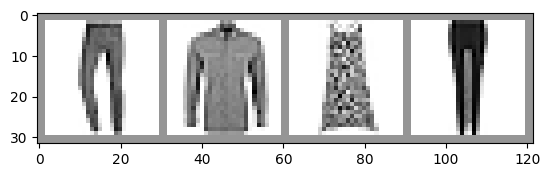

In [10]:
# =============================================================================
# 7 — Write a sample image grid to TensorBoard
# =============================================================================
# Grab one batch of 4 images, arrange them in a grid, display inline,
# and also log the grid so it shows up under the "Images" tab in TB.

dataiter = iter(trainloader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)   # 4 images side-by-side

matplotlib_imshow(img_grid, one_channel=True)     # show in notebook
writer.add_image('four_fashion_mnist_images', img_grid)  # log to TB



In [11]:
# =============================================================================
# 8 — Log the model graph
# =============================================================================
# add_graph traces a forward pass of `images` through `net` and records
# the computational graph. Visible under the "Graphs" tab in TB.
# writer.close() flushes pending events to disk.

writer.add_graph(net, images)
writer.close()

In [18]:
# =============================================================================
# 9 — Add an embedding projector
# =============================================================================
# Randomly pick 100 images, flatten each 28×28 image into a 784-D vector,
# and log them as embeddings. TensorBoard's Projector tab will run PCA / t-SNE
# to project them into 2-D or 3-D for interactive exploration.

def select_n_random(data, labels, n=100):
    """Selects n random datapoints and their corresponding labels."""
    assert len(data) == len(labels)
    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

# trainset.data is the raw uint8 tensor (60000×28×28)
images, labels = select_n_random(trainset.data, trainset.targets)

class_labels = [classes[lab] for lab in labels]  # int → string labels

# Flatten to 784-D feature vectors; unsqueeze adds a channel dim for thumbnails
features = images.view(-1, 28 * 28)
writer.add_embedding(
    features,
    metadata=class_labels,
    label_img=images.unsqueeze(1)   # shape: (100, 1, 28, 28) for grayscale thumbnails
)
writer.close()

In [19]:
# =============================================================================
# 10 — Helper functions for training visualisation
# =============================================================================

def images_to_probs(net, images):
    """
    Forward-pass a batch of images through `net`.
    Returns:
        preds  — predicted class indices (numpy array)
        probs  — confidence (softmax probability) for each prediction
    """
    output = net(images)
    _, preds_tensor = torch.max(output, 1)       # argmax along class dim
    preds = np.squeeze(preds_tensor.numpy())
    # For each sample, grab the softmax probability at the predicted index
    return preds, [F.softmax(el, dim=0)[i].item() for i, el in zip(preds, output)]


def plot_classes_preds(net, images, labels):
    """
    Build a matplotlib Figure showing 4 images with:
      - predicted class + confidence %
      - actual label
      - green title if correct, red if wrong
    """
    preds, probs = images_to_probs(net, images)
    fig = plt.figure(figsize=(12, 48))
    for idx in np.arange(4):
        ax = fig.add_subplot(1, 4, idx + 1, xticks=[], yticks=[])
        matplotlib_imshow(images[idx], one_channel=True)
        ax.set_title(
            "{0}, {1:.1f}%\n(label: {2})".format(
                classes[preds[idx]],
                probs[idx] * 100.0,
                classes[labels[idx]]),
            color=("green" if preds[idx] == labels[idx].item() else "red"))
    return fig


In [14]:
# =============================================================================
# 11 — Training loop with TensorBoard logging
# =============================================================================
# Runs 1 epoch over the full training set (~15,000 mini-batches of size 4).
# Every 1,000 batches:
#   • Logs the average loss over those 1,000 steps  → "Scalars" tab
#   • Logs a figure of predictions vs. ground truth → "Images" tab
#
# The global_step (epoch * total_batches + i) gives a unique x-axis value.

running_loss = 0.0

for epoch in range(1):  # single epoch for demo; increase for real training
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data

        optimizer.zero_grad()          # reset gradients from previous step

        outputs = net(inputs)          # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                # compute gradients
        optimizer.step()               # update weights

        running_loss += loss.item()

        if i % 1000 == 999:            # every 1,000 mini-batches
            # Log average training loss over the last 1,000 batches
            writer.add_scalar(
                'training loss',
                running_loss / 1000,
                epoch * len(trainloader) + i)

            # Log a figure comparing predictions to actual labels
            writer.add_figure(
                'predictions vs. actuals',
                plot_classes_preds(net, inputs, labels),
                global_step=epoch * len(trainloader) + i)

            running_loss = 0.0

print('Finished Training')

Finished Training


In [ ]:
# =============================================================================
# 12 — Evaluate on test set & log precision-recall curves
# =============================================================================
# Run inference on the entire test set (no gradient computation needed).
# Collect softmax probabilities and true labels for all 10,000 test images.

class_probs = []
class_label = []

with torch.no_grad():                     # disable autograd for speed
    for data in testloader:
        images, labels = data
        output = net(images)
        # Convert logits → probabilities for each sample in the batch
        class_probs_batch = [F.softmax(el, dim=0) for el in output]
        class_probs.append(class_probs_batch)
        class_label.append(labels)

# Stack into tensors: test_probs is (10000, 10), test_label is (10000,)
test_probs = torch.cat([torch.stack(batch) for batch in class_probs])
test_label = torch.cat(class_label)


def add_pr_curve_tensorboard(class_index, test_probs, test_label, global_step=0):
    """
    For one class, compute a precision-recall curve and log it to TB.
    `tensorboard_truth` is a boolean mask: True where the label matches.
    `tensorboard_probs` is the model's estimated probability for that class.
    """
    tensorboard_truth = test_label == class_index
    tensorboard_probs = test_probs[:, class_index]

    writer.add_pr_curve(
        classes[class_index],
        tensorboard_truth,
        tensorboard_probs,
        global_step=global_step)
    writer.close()

# Log a PR curve for each of the 10 classes → visible under "PR Curves" tab
for i in range(len(classes)):
    add_pr_curve_tensorboard(i, test_probs, test_label)


In [21]:
# =============================================================================
# 13 — Launch TensorBoard (run in a notebook cell or terminal)
# =============================================================================
# Option A: inline in Jupyter / Colab
# %load_ext tensorboard
# %tensorboard --logdir=runs

# Option B: from the terminal
# tensorboard --logdir=runs
# Then open http://localhost:6006 in your browser.